# 01 - Inspeção inicial do dataset

**Objetivo:** entender o que há no dataset bruto do Stack Overflow Developer Survey 2025 antes de qualquer limpeza ou transformação.

**Perguntas a responder:**
1. Quantas respostas tem o dataset total?
2. Quantas sobrevivem aos filtros mínimos da pergunta de pesquisa?
3. Como é a distribuição do salário (`ConvertedCompYearly`)?
4. Quais são as 20 linguagens mais frequentes na amostra filtrada?

> Este notebook **não modifica dados**. É apenas diagnóstico. As transformações ficam para o notebook `02_limpeza`.

## 1. Setup

Imports e configurações visuais compartilhadas pelo notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

pd.set_option('display.max_columns', 100)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 2. Carregamento

Das 172 colunas disponíveis no CSV bruto, carregamos apenas 9 — as que têm papel definido na pergunta de pesquisa. Ver `CONTEXT.md` para a justificativa de cada coluna.

Usar `usecols` economiza ~93% de memória e deixa a análise mais rápida.

In [2]:
colunas_necessarias = [
    'ResponseId',              # identificador único - rastreabilidade
    'MainBranch',              # filtro - devs profissionais
    'Employment',              # filtro - status de emprego
    'ConvertedCompYearly',     # variável dependente Y - salário em USD
    'LanguageHaveWorkedWith',  # variável explicativa principal X
    'YearsCode',               # controle - anos de código (proxy de experiência)
    'Country',                 # controle - país
    'EdLevel',                 # controle - formação
    'DevType',                 # controle e segmentação - tipo de dev
]

df = pd.read_csv("../data/raw/survey_results_public.csv", usecols=colunas_necessarias)

print(f"Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"Memória utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Dimensões: 49,191 linhas × 9 colunas
Memória utilizada: 23.7 MB


## 3. Visão inicial dos dados

Antes de qualquer análise, três inspeções rápidas:
- **Amostra visual** das primeiras linhas (confirma que o carregamento foi correto)
- **Tipos de dados** (detecta colunas com tipo inesperado)
- **Valores ausentes** (antecipa o custo de cada filtro futuro)

In [3]:
df.head()

,ResponseId,MainBranch,EdLevel,Employment,YearsCode,DevType,Country,LanguageHaveWorkedWith,ConvertedCompYearly
0,1,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,14.0,"Developer, mobile",Ukraine,Bash/Shell (all shells);Dart;SQL,61256.0
1,2,I am a developer by profession,"Associate degree (A.A., A.S., etc.)",Employed,10.0,"Developer, back-end",Netherlands,Java,104413.0
2,3,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",12.0,"Developer, front-end",Ukraine,Dart;HTML/CSS;JavaScript;TypeScript,53061.0
3,4,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,5.0,"Developer, back-end",Ukraine,Java;Kotlin;SQL,36197.0
4,5,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",22.0,Engineering manager,Ukraine,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,60000.0


In [4]:
print("Tipos de dados:")
print(df.dtypes)
print()

ausentes = df.isna().sum()
percentual = (ausentes / len(df) * 100).round(1)
resumo_ausentes = pd.DataFrame({
    'Ausentes': ausentes,
    'Percentual (%)': percentual
})

print("Valores ausentes por coluna:")
print(resumo_ausentes)

Tipos de dados:
ResponseId                  int64
MainBranch                    str
EdLevel                       str
Employment                    str
YearsCode                 float64
DevType                       str
Country                       str
LanguageHaveWorkedWith        str
ConvertedCompYearly       float64
dtype: object

Valores ausentes por coluna:
                        Ausentes  Percentual (%)
ResponseId                     0             0.0
MainBranch                     0             0.0
EdLevel                     1042             2.1
Employment                   852             1.7
YearsCode                   6149            12.5
DevType                     5511            11.2
Country                    13754            28.0
LanguageHaveWorkedWith     17520            35.6
ConvertedCompYearly        25244            51.3


## 4. Valores das colunas de filtro

Antes de filtrar, precisamos conhecer os valores reais de `MainBranch` e `Employment`. Comparar strings exige os nomes exatos qualquer divergência silenciosa faz o filtro ignorar linhas.

In [5]:
print("MainBranch - distribuição de valores:")
print(df['MainBranch'].value_counts(dropna=False))
print()
print("Employment - distribuição de valores:")
print(df['Employment'].value_counts(dropna=False))

MainBranch - distribuição de valores:
MainBranch
I am a developer by profession                                                                37467
I am not primarily a developer, but I write code sometimes as part of my work/studies          4894
I am learning to code                                                                          2585
I code primarily as a hobby                                                                    1924
I used to be a developer by profession, but no longer am                                       1325
I work with developers or my work supports developers but am not a developer by profession      996
Name: count, dtype: int64

Employment - distribuição de valores:
Employment
Employed                                                33750
Independent contractor, freelancer, or self-employed     6708
Student                                                  4428
Not employed                                             2227
NaN                        

## 5. Pipeline de filtragem

Aplicamos 4 filtros em sequência, reportando quantas linhas sobrevivem a cada passo. Cada filtro tem justificativa ligada à pergunta de pesquisa e nesse caso respondemos a pergunta dois.

In [6]:
total_inicial = len(df)
print(f"{'Total inicial de respostas':.<60} {total_inicial:>8,}")

# Filtro 1: só devs profissionais
# Justificativa: a pergunta é sobre salário de desenvolvedores
df_filtrado = df[df['MainBranch'] == 'I am a developer by profession']
print(f"{'Após MainBranch = devs profissionais':.<60} {len(df_filtrado):>8,}")

# Filtro 2: só empregados ou freelancers
# Justificativa: precisamos de devs com salário atual válido
empregados_validos = [
    'Employed',
    'Independent contractor, freelancer, or self-employed',
]
df_filtrado = df_filtrado[df_filtrado['Employment'].isin(empregados_validos)]
print(f"{'Após Employment = empregado/freelancer':.<60} {len(df_filtrado):>8,}")

# Filtro 3: respondeu salário
# Justificativa: salário é a variável dependente; sem ela não há modelo
df_filtrado = df_filtrado[df_filtrado['ConvertedCompYearly'].notna()]
print(f"{'Após respondeu salário':.<60} {len(df_filtrado):>8,}")

# Filtro 4: respondeu linguagens
# Justificativa: linguagens é a variável explicativa principal
df_filtrado = df_filtrado[df_filtrado['LanguageHaveWorkedWith'].notna()]
print(f"{'Após respondeu linguagens':.<60} {len(df_filtrado):>8,}")

print()
print(f"{'AMOSTRA FINAL PARA ANÁLISE':.<60} {len(df_filtrado):>8,}")
print(f"{'% do total original retido':.<60} {len(df_filtrado)/total_inicial*100:>7.1f}%")

Total inicial de respostas..................................   49,191
Após MainBranch = devs profissionais........................   37,467
Após Employment = empregado/freelancer......................   34,146
Após respondeu salário......................................   19,472
Após respondeu linguagens...................................   18,191

AMOSTRA FINAL PARA ANÁLISE..................................   18,191
% do total original retido..................................    37.0%


## 6. Persistência da amostra filtrada

Salvamos `df_filtrado` em `data/processed/` para reuso nos próximos notebooks. Usamos CSV, suficiente para o volume do dataset (~18k linhas).

## 7. Distribuição do salário

Para a pergunta três, examinamos a distribuição de `ConvertedCompYearly` por dois ângulos complementares:
- **Estatísticas descritivas** (`describe()`): números-chave que caracterizam o centro e a dispersão
- **Histogramas** em escala linear e escala log: formato visual da distribuição

In [8]:
print("Estatísticas descritivas de ConvertedCompYearly (USD):")
print(df_filtrado['ConvertedCompYearly'].describe())

Estatísticas descritivas de ConvertedCompYearly (USD):
count    1.819100e+04
mean     1.016055e+05
std      2.918781e+05
min      1.000000e+00
25%      4.550900e+04
50%      8.025400e+04
75%      1.259655e+05
max      3.355272e+07
Name: ConvertedCompYearly, dtype: float64


In [9]:
# Desativa notação científica e define formato decimal com 2 casas
pd.options.display.float_format = '{:,.2f}'.format

# Mostra o describe() de novo em formato legível
print("Estatísticas descritivas de ConvertedCompYearly (USD):")
print(df_filtrado['ConvertedCompYearly'].describe())

Estatísticas descritivas de ConvertedCompYearly (USD):
count       18,191.00
mean       101,605.48
std        291,878.09
min              1.00
25%         45,509.00
50%         80,254.00
75%        125,965.50
max     33,552,715.00
Name: ConvertedCompYearly, dtype: float64


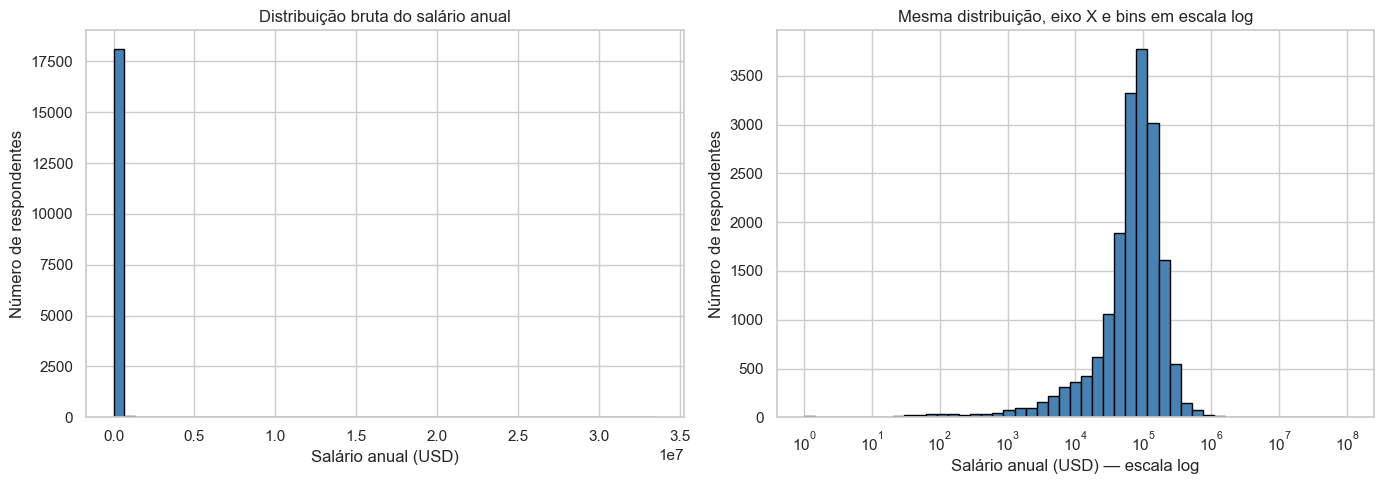

In [10]:
# Par de histogramas: linear (deixa evidente o problema dos outliers)
# vs log (revela a forma real da distribuição lognormal)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

salario = df_filtrado['ConvertedCompYearly']

# Gráfico 1: escala linear
# Esperado: cauda longa esmaga os valores centrais (justifica a transformação log)
axes[0].hist(salario, bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('Distribuição bruta do salário anual')
axes[0].set_xlabel('Salário anual (USD)')
axes[0].set_ylabel('Número de respondentes')

# Gráfico 2: escala log no eixo X + bins logaritmicamente espaçados
# np.logspace(0, 8, 50) = 50 bins entre 10^0 e 10^8, igualmente espaçados no log
bins_log = np.logspace(0, 8, 50)
axes[1].hist(salario, bins=bins_log, edgecolor='black', color='steelblue')
axes[1].set_xscale('log')
axes[1].set_title('Mesma distribuição, eixo X e bins em escala log')
axes[1].set_xlabel('Salário anual (USD) — escala log')
axes[1].set_ylabel('Número de respondentes')

plt.tight_layout()
plt.savefig('../output/figures/01_histograma_salario_bruto_vs_log.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Top linguagens

`LanguageHaveWorkedWith` é multirresposta (várias linguagens por dev, separadas por `;`). Para contar corretamente, fazemos **split + explode**: cada linguagem vira uma linha separada, depois `value_counts()` conta normalmente e assim, respondemos a pergunta 4.

In [11]:
linguagens_por_dev = df_filtrado['LanguageHaveWorkedWith'].str.split(';')
todas_linguagens = linguagens_por_dev.explode()
contagem_linguagens = todas_linguagens.value_counts()

print(f"Total de linguagens distintas citadas: {contagem_linguagens.shape[0]}")
print()
print("Top 25 linguagens mais frequentes na amostra filtrada:")
print(contagem_linguagens.head(25))

Total de linguagens distintas citadas: 42

Top 25 linguagens mais frequentes na amostra filtrada:
LanguageHaveWorkedWith
JavaScript                 12589
HTML/CSS                   11510
SQL                        11377
Python                      9946
TypeScript                  9196
Bash/Shell (all shells)     9073
C#                          5553
Java                        5190
PowerShell                  4319
C++                         3605
PHP                         3334
Go                          3205
C                           3054
Rust                        2548
Kotlin                      2090
Lua                         1480
Ruby                        1318
Swift                       1032
Dart                        1011
Groovy                       996
Assembly                     821
Visual Basic (.Net)          741
Perl                         596
VBA                          581
R                            539
Name: count, dtype: int64


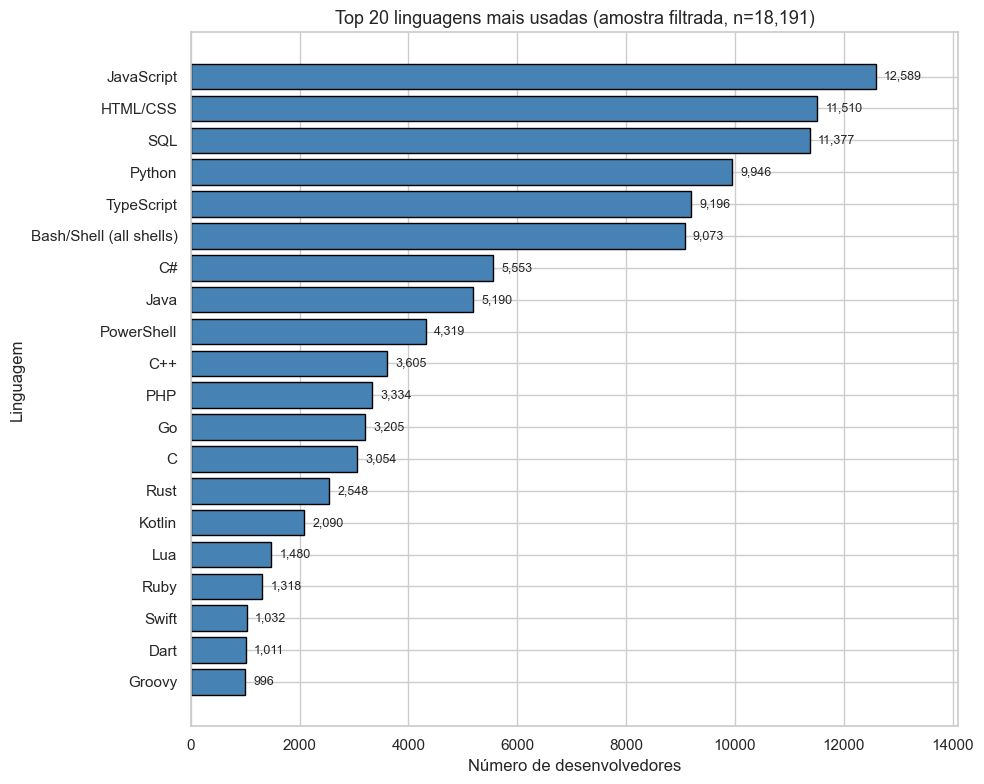

In [12]:
# Gráfico de barras horizontal (rótulos longos não cabem na vertical)
top_20 = contagem_linguagens.head(20).iloc[::-1]  # inverte: mais frequente no topo

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_20.index, top_20.values, color='steelblue', edgecolor='black')

ax.set_title(f'Top 20 linguagens mais usadas (amostra filtrada, n={len(df_filtrado):,})', fontsize=13)
ax.set_xlabel('Número de desenvolvedores')
ax.set_ylabel('Linguagem')

# Anota o valor exato no fim de cada barra
for i, valor in enumerate(top_20.values):
    ax.text(valor + 150, i, f'{valor:,}', va='center', fontsize=9)

ax.set_xlim(0, top_20.values.max() * 1.12)
plt.tight_layout()
plt.savefig('../output/figures/01_top20_linguagens.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Conclusões

### Respostas às perguntas de diagnóstico

**1. Tamanho do dataset bruto:** 49.191 respondentes.

**2. Amostra final após filtros metodológicos:** 18.191 respondentes (37,0% do total original).

Os critérios de inclusão aplicados foram:
- Ser desenvolvedor profissional (exclusão de estudantes, hobbistas e profissões afins)
- Estar empregado ou atuar como freelancer (exclusão de desempregados e aposentados)
- Ter informado salário anual
- Ter informado linguagens de programação utilizadas

A perda mais expressiva ocorreu no critério salarial: 51,3% dos respondentes não informaram remuneração, o que é esperado em pesquisas sobre renda.

**3. Distribuição do salário anual (USD):** fortemente assimétrica à direita.

| Estatística | Valor |
|---|---|
| Mediana | `US$ 80.254` |
| Média | `US$ 101.606` |
| Mínimo observado | `US$ 1` |
| Máximo observado | `US$ 33.552.715` |
| Desvio padrão | `US$ 291.878` |

A razão entre desvio padrão e média (cerca de 3:1) e a discrepância entre média e mediana confirmam forte assimetria positiva. Os extremos observados (US$ 1 e US$ 33,5 milhões) evidenciam a presença de valores atípicos que precisarão ser tratados antes da modelagem.

**4. Linguagens de programação mais frequentes:** das 42 linguagens distintas citadas, as seis mais frequentes (JavaScript, HTML/CSS, SQL, Python, TypeScript e Bash/Shell) foram mencionadas por mais de 9.000 respondentes cada. O gráfico acima apresenta a distribuição completa entre as 20 mais utilizadas.

### Observações metodológicas

A inspeção revela três características dos dados que justificam tratamento antes da análise de regressão:

- A distribuição assimétrica do salário indica a necessidade de **transformação logarítmica** da variável dependente, prática padrão em estudos econométricos de remuneração.
- A presença de **valores atípicos extremos** em ambas as caudas da distribuição de salário exige filtragem estatística (por exemplo, corte por percentis).
- A variável `LanguageHaveWorkedWith` é multirresposta e precisará ser transformada em **variáveis indicadoras (dummies)** para cada linguagem selecionada como regressor.

Essas etapas serão executadas na fase de limpeza e transformação dos dados.